# 02 — Custom CNN Training

**Brain Tumor Detection** — Model 1 of 3.

Trains the `BrainTumorCNN` (≈1.21 M params) on the stratified train/val
split created in STEP 3, using the augmentation pipeline from STEP 5
and the training engine from `src/train.py`.

Expected total run time on an RTX 3060: ~6 min. On a GTX 1650: ~12–18 min.

Outputs:
* `models/cnn_model.pth`               — best checkpoint by val_acc
* `outputs/reports/cnn_history.json`   — per-epoch metrics
* `outputs/plots/cnn_training_curves.png`
* `outputs/confusion_matrices/cnn_val_cm.png`
* `logs/cnn/`                          — TensorBoard event files

In [1]:
# --- 0. Setup ---------------------------------------------------------
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src' / '__init__.py').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.config import (
    CLASS_NAMES, NUM_CLASSES, BATCH_SIZE, NUM_WORKERS, IMG_SIZE,
    OUTPUTS_DIR, MODELS_DIR, LOGS_DIR,
)
from src.data_loader import get_dataloaders
from src.cnn_model   import build_cnn
from src.train       import fit, evaluate, plot_history
from src.evaluate    import (
    logits_to_preds, build_classification_report,
    plot_confusion_matrix, per_class_metrics_df,
)
from src.utils       import get_device, set_seed, count_parameters

set_seed(42)
device = get_device()
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

Device : cuda
GPU    : NVIDIA GeForce GTX 1650


## 1. DataLoaders

Train uses augmentations (`get_train_transform`); val uses the deterministic pipeline.

In [2]:
train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)
print(f'Train batches: {len(train_loader)}  ({len(train_loader.dataset)} images)')
print(f'Val   batches: {len(val_loader)}    ({len(val_loader.dataset)} images)')
print(f'Test  batches: {len(test_loader)}   ({len(test_loader.dataset)} images)')

Train batches: 140  (4480 images)
Val   batches: 35    (1120 images)
Test  batches: 50   (1600 images)


## 2. Build the model

Trainable parameter count printed below should match the ~1.21 M from STEP 6.

In [3]:
model = build_cnn(num_classes=NUM_CLASSES, dropout=0.5)
print(f'Trainable parameters: {count_parameters(model):,}')

Trainable parameters: 1,206,628


## 3. Train

Calls the reusable `fit()` engine. The first epoch is slow on Windows
(DataLoader worker spawn) — every subsequent epoch will be faster.

Training will run up to 25 epochs but will early-stop after 7 epochs
without validation-accuracy improvement.

In [ ]:
import torch as _torch

RUN_NAME = 'cnn'

# NOTE on hardware tuning:
#   * 12 epochs is a deliberate budget for the 4 GB GTX 1650 (~32 min total).
#     Loss is still improving at epoch 12 but the marginal gains are small.
#   * `amp_dtype=bfloat16`: fp16 triggers a cuDNN NaN bug on this Turing GPU
#     for the (64, 64, 3) conv pattern, so we use bf16 which has fp32's
#     dynamic range. On Ampere/Ada you can switch back to fp16 for ~10% more speed.

model, history, best_val_acc = fit(
    model         = model,
    train_loader  = train_loader,
    val_loader    = val_loader,
    epochs        = 12,
    lr            = 3e-4,             # from-scratch CNN: slightly higher than pretrained
    weight_decay  = 1e-4,
    patience      = 5,
    use_amp       = (device.type == 'cuda'),
    amp_dtype     = _torch.bfloat16,
    run_name      = RUN_NAME,
    checkpoint_path = MODELS_DIR / 'cnn_model.pth',
    log_dir         = LOGS_DIR    / 'cnn',
    history_path    = OUTPUTS_DIR / 'reports' / 'cnn_history.json',
    seed          = 42,
)

[fit] run_name        = cnn
[fit] device          = cuda
[fit] trainable params = 1,206,628
[fit] train batches    = 140 | val batches = 35
[fit] lr=3e-04  wd=1e-04  amp=True(torch.bfloat16)  epochs=12  patience=5
[fit] checkpoint -> C:\Brain Tumor Detection\models\cnn_model.pth
[fit] tensorboard -> C:\Brain Tumor Detection\logs\cnn



E01/12 train:   0%|          | 0/140 [00:16<?, ?it/s]

E01/12 val:   0%|          | 0/35 [00:19<?, ?it/s]

Epoch 01/12  train_loss=1.0617 train_acc=0.5571  |  val_loss=0.7517 val_acc=0.7304  lr=2.95e-04  time=195.5s  <- best


E02/12 train:   0%|          | 0/140 [00:00<?, ?it/s]

...

E11/12 val:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 11/12  train_loss=0.3856 train_acc=0.8598  |  val_loss=0.2749 val_acc=0.8991  lr=8.06e-06  time=151.3s  <- best


E12/12 train:   0%|          | 0/140 [00:00<?, ?it/s]

E12/12 val:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 12/12  train_loss=0.3753 train_acc=0.8663  |  val_loss=0.2687 val_acc=0.9036  lr=3.00e-06  time=156.4s  <- best

[fit] Done in 32.1 min
[fit] Best val_acc = 0.9036 (epoch 12)
[fit] Best val_loss= 0.2687
[fit] Checkpoint saved -> C:\Brain Tumor Detection\models\cnn_model.pth
[fit] History saved    -> C:\Brain Tumor Detection\outputs\reports\cnn_history.json


## 4. Training curves

Look for: train and val curves moving together (healthy) vs. val
plateauing while train keeps falling (overfitting).

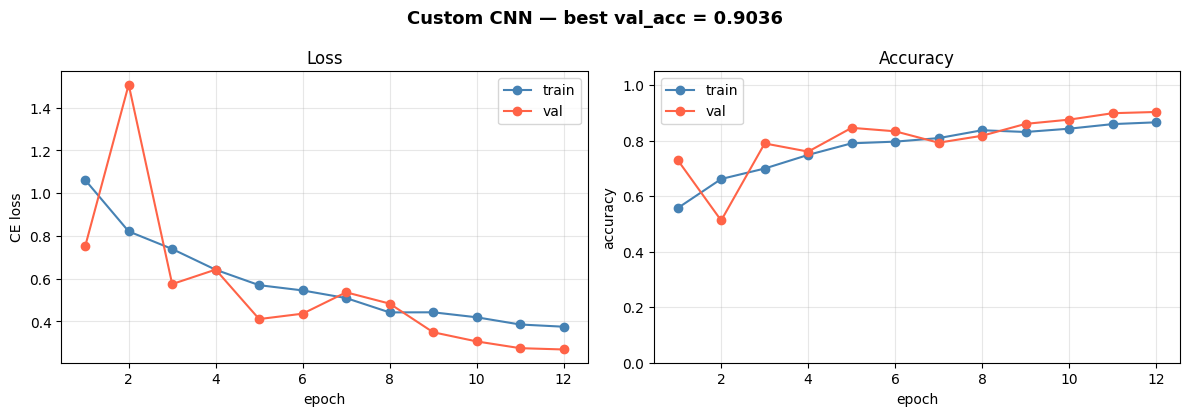

In [5]:
fig = plot_history(
    history,
    save_path = OUTPUTS_DIR / 'plots' / 'cnn_training_curves.png',
    title     = f'Custom CNN — best val_acc = {best_val_acc:.4f}',
)
plt.show()

## 5. Validation evaluation — confusion matrix

Reload the best checkpoint (already loaded by `fit()`) and run a full
evaluation pass on the validation set to get logits for every image.

final val:   0%|          | 0/35 [00:00<?, ?it/s]

Final val loss: 0.2687
Final val acc : 0.9036


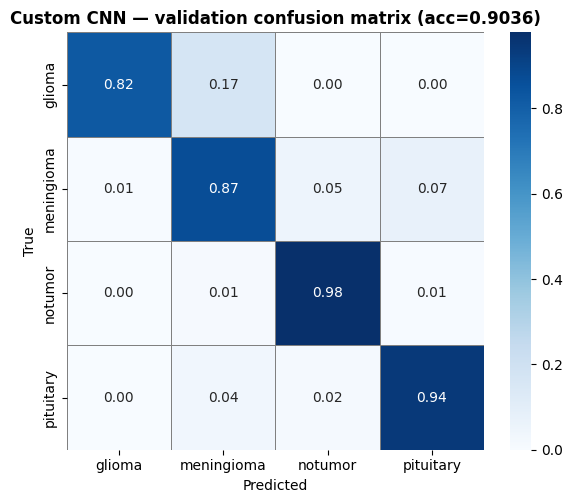

In [6]:
import torch.nn as nn

val_loss, val_acc, val_logits, val_labels = evaluate(
    model, val_loader, nn.CrossEntropyLoss(), device,
    use_amp=(device.type == 'cuda'),
    desc='final val',
    return_predictions=True,
)
y_pred = logits_to_preds(val_logits)
y_true = val_labels.numpy()
print(f'Final val loss: {val_loss:.4f}')
print(f'Final val acc : {val_acc:.4f}')

fig = plot_confusion_matrix(
    y_true, y_pred, CLASS_NAMES,
    normalize=True,
    title=f'Custom CNN — validation confusion matrix (acc={val_acc:.4f})',
    save_path=OUTPUTS_DIR / 'confusion_matrices' / 'cnn_val_cm.png',
)
plt.show()

## 6. Classification report (per-class precision / recall / F1)

In [7]:
text, _ = build_classification_report(y_true, y_pred, CLASS_NAMES)
print(text)

df = per_class_metrics_df(y_true, y_pred, CLASS_NAMES)
df_display = df.copy()
for c in ['precision', 'recall', 'f1']:
    df_display[c] = df_display[c].round(4)
print(df_display.to_string(index=False))

              precision    recall  f1-score   support

      glioma     0.9872    0.8250    0.8988       280
  meningioma     0.7967    0.8679    0.8308       280
     notumor     0.9352    0.9786    0.9564       280
   pituitary     0.9167    0.9429    0.9296       280

    accuracy                         0.9036      1120
   macro avg     0.9089    0.9036    0.9039      1120
weighted avg     0.9089    0.9036    0.9039      1120

     class  precision  recall     f1  support
    glioma     0.9872  0.8250 0.8988      280
meningioma     0.7967  0.8679 0.8308      280
   notumor     0.9352  0.9786 0.9564      280
 pituitary     0.9167  0.9429 0.9296      280


## 7. Summary

Artifacts produced by this notebook:

* `models/cnn_model.pth`                            — best CNN weights
* `outputs/reports/cnn_history.json`                — per-epoch metrics
* `outputs/plots/cnn_training_curves.png`           — loss + accuracy curves
* `outputs/confusion_matrices/cnn_val_cm.png`       — normalized CM on val
* `logs/cnn/`                                       — TensorBoard events

**Next:** STEP 8 — Transfer Learning model (ResNet50 / EfficientNet).